In [ ]:
import yfinance as yf
import pandas as pd
import os

DATA_DIR = "data"

def download_and_save(ticker, start="2006-01-01", end="2026-01-01"):
    df = yf.download(ticker, start=start, end=end, interval="1d")
    df = df[['Open','High','Low','Close','Volume']]
    df.columns = ['open','high','low','close','volume']
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    os.makedirs(DATA_DIR, exist_ok=True)
    filename = ticker.replace("^", "")
    path = os.path.join(DATA_DIR, f"{filename}.csv")
    df.to_csv(path)
    print(f"Saved {ticker} → {path}")

def download_all():
    stocks = [
        "AAPL", "MSFT", "GOOGL", "AMZN", "META",
        "NVDA", "TSLA", "AMD", "INTC", "CSCO"
    ]
    market = ["^GSPC", "^IXIC", "^VIX"]
    for ticker in stocks + market:
        download_and_save(ticker)

if __name__ == "__main__":
    download_all()

[*********************100%***********************]  1 of 1 completed


Saved AAPL → data\AAPL.csv


[*********************100%***********************]  1 of 1 completed


Saved MSFT → data\MSFT.csv


[*********************100%***********************]  1 of 1 completed


...

Saved ^GSPC → data\GSPC.csv


[*********************100%***********************]  1 of 1 completed


Saved ^IXIC → data\IXIC.csv


[*********************100%***********************]  1 of 1 completed

Saved ^VIX → data\VIX.csv


In [ ]:
import os
import pandas as pd
DATA_DIR = "data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)
TRAIN_END = pd.Timestamp("2021-01-01")
VAL_END = pd.Timestamp("2024-01-01")
TEST_END = pd.Timestamp("2026-01-01")
for filename in os.listdir(DATA_DIR):
    if filename in ["train", "val", "test"]:
        continue
    file_path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(file_path)
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    df = df.rename(columns={df.columns[0]: "date"})
    df = df.set_index("date")
    df = df[~df.index.isna()]
    df = df.sort_index()
    df_train = df[(df.index >= "2006-01-01") & (df.index < TRAIN_END)]
    df_val   = df[(df.index >= TRAIN_END) & (df.index < VAL_END)]
    df_test  = df[(df.index >= VAL_END) & (df.index < TEST_END)]
    base = os.path.splitext(filename)[0]
    df_train.to_csv(os.path.join(TRAIN_DIR, f"{base}_train.csv"))
    df_val.to_csv(os.path.join(VAL_DIR, f"{base}_val.csv"))
    df_test.to_csv(os.path.join(TEST_DIR, f"{base}_test.csv"))
    print(f"{filename}")
    print(f"   Train: {len(df_train)} rows")
    print(f"   Val:   {len(df_val)} rows")
    print(f"   Test:  {len(df_test)} rows\n")
print("Done splitting train/val/test.")

c:\Users\admin\Desktop\RL\venv\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
c:\Users\admin\Desktop\RL\venv\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
c:\Users\admin\Desktop\RL\venv\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.


AAPL.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

AMD.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

AMZN.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

CSCO.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

GOOGL.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

INTC.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

META.csv
   Train: 2170 rows
   Val:   753 rows
   Test:  502 rows

MSFT.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

NVDA.csv
   Train: 3776 rows
   Val:   753 rows
   Test:  502 rows

TSLA.csv
   Train: 2647 rows
   Val:   753 rows
   Test:  502 rows

Done splitting train/val/test.


c:\Users\admin\Desktop\RL\venv\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
c:\Users\admin\Desktop\RL\venv\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
c:\Users\admin\Desktop\RL\venv\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.


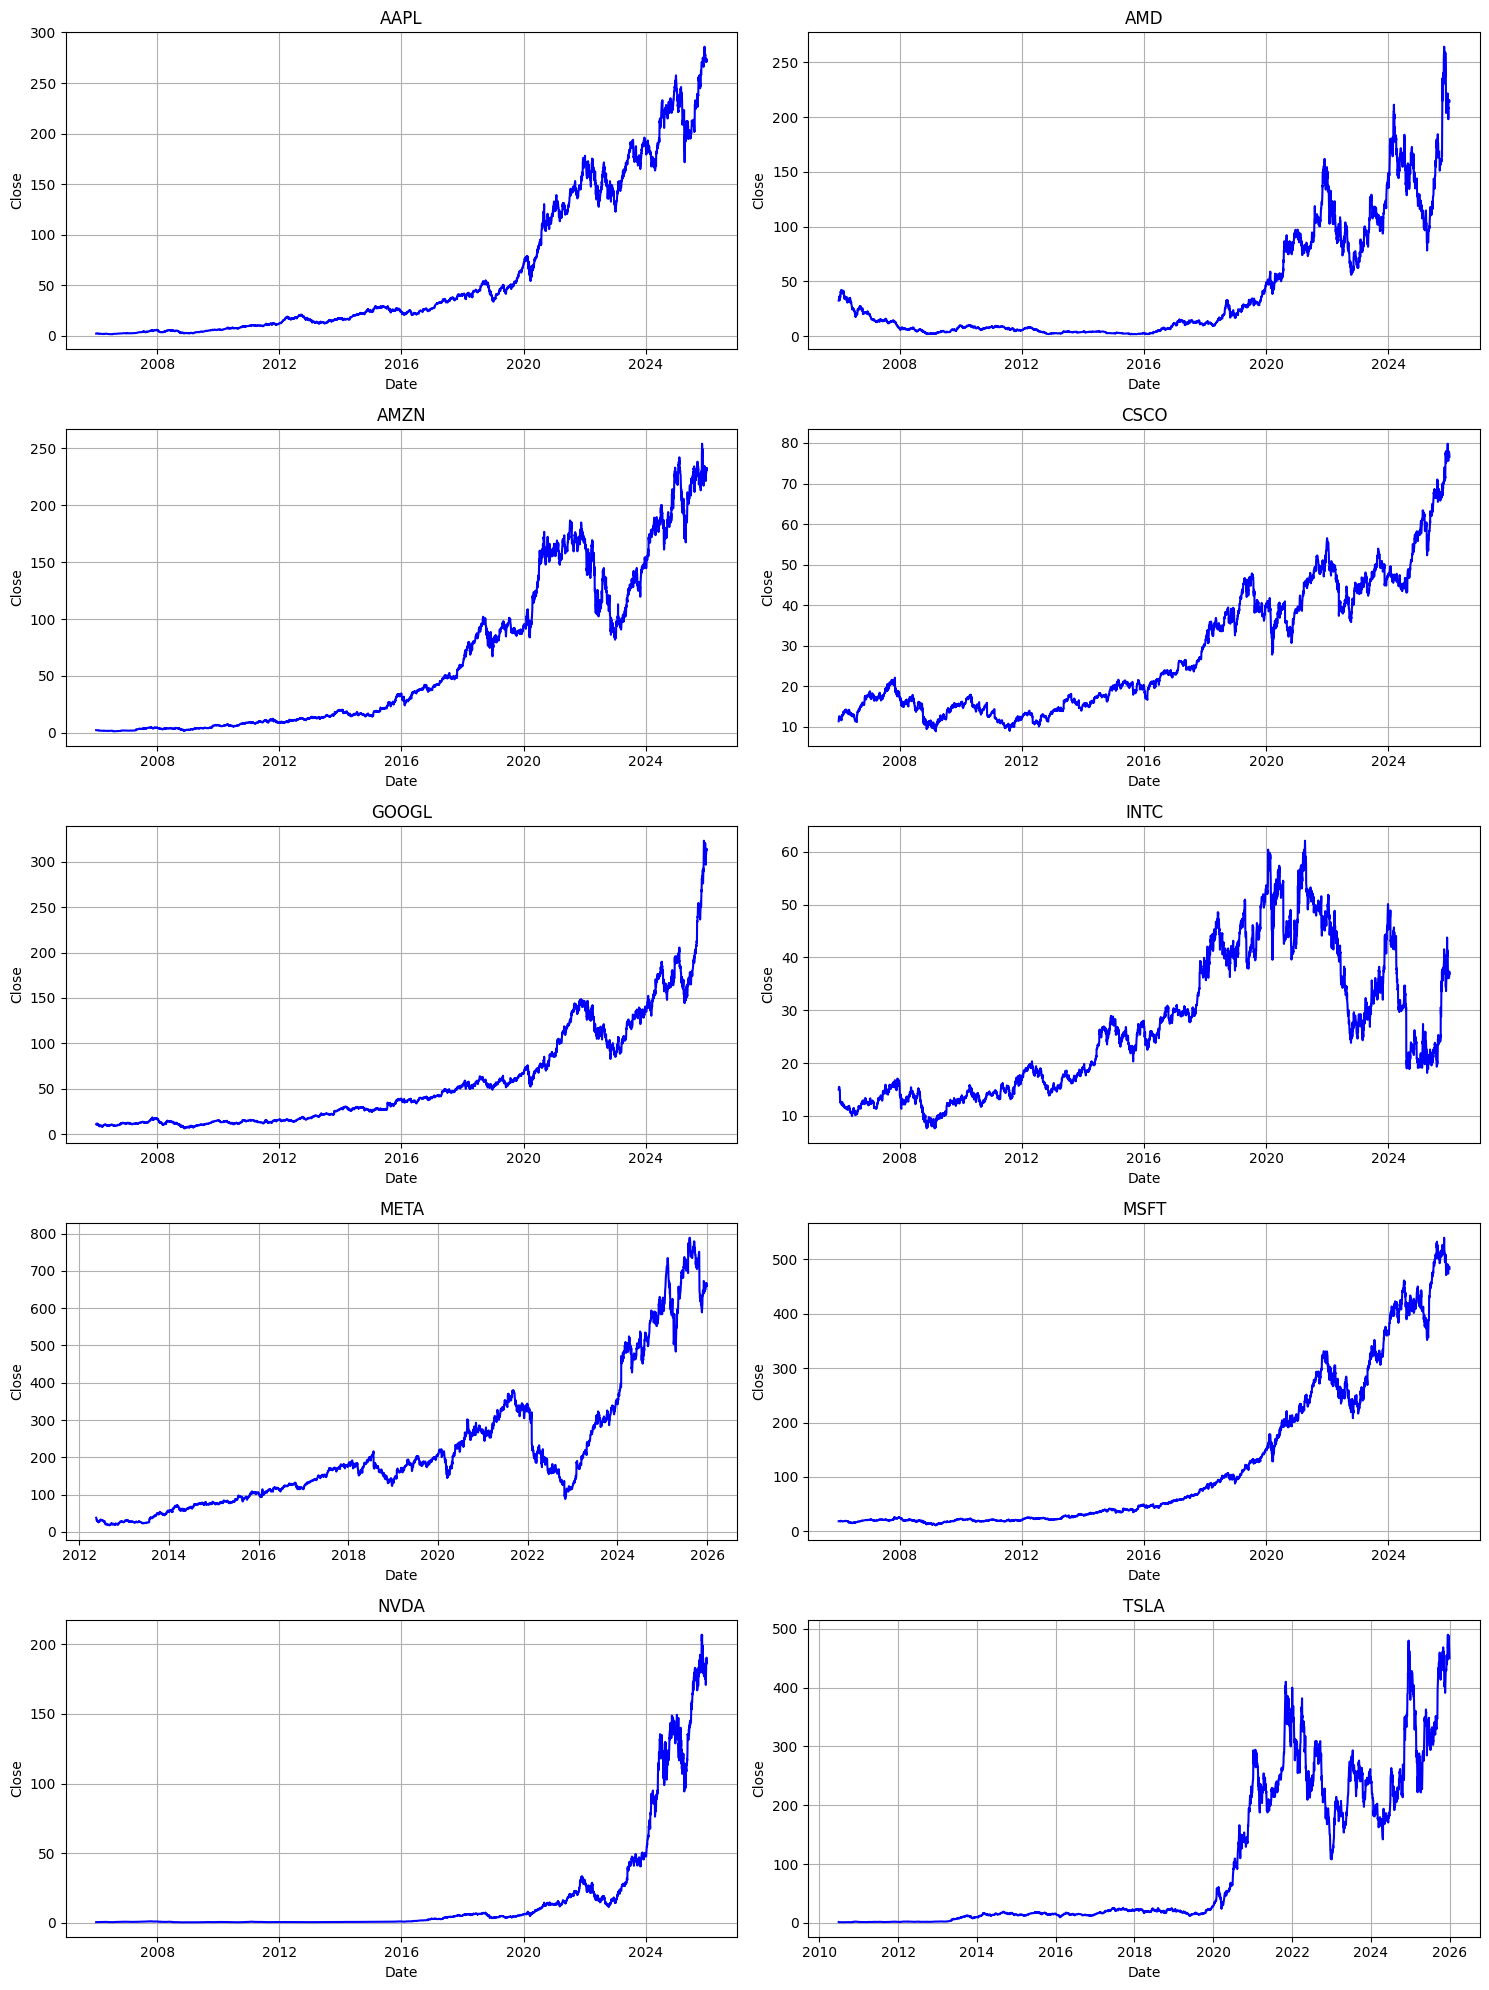

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

files = glob.glob("data/*.csv")
data_close = {}

for file in files:
    df = pd.read_csv(file, parse_dates=['Date'])
    ticker = os.path.basename(file).replace('.csv','')
    df = df.sort_values('Date')
    data_close[ticker] = df.set_index('Date')['close']

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, ticker in enumerate(data_close.keys()):
    axes[i].plot(data_close[ticker].index, data_close[ticker], color='blue')
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Close')
    axes[i].grid(True)

plt.tight_layout()
plt.show()